In [1]:
!pip install xarray
!pip install zarr
!pip install gcsfs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 75.0 MB/s eta 0:00:00


In [2]:
import xarray as xr

ds = xr.open_zarr(
    "gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-64x32_equiangular_conservative.zarr",
    storage_options={"token": "anon"}
)

print(ds)

<xarray.Dataset> Size: 175GB
Dimensions:                                           (time: 93544,
                                                       longitude: 64,
                                                       latitude: 32, level: 13)
Coordinates:
  * time                                              (time) datetime64[ns] 748kB ...
  * longitude                                         (longitude) float64 512B ...
  * latitude                                          (latitude) float64 256B ...
  * level                                             (level) int64 104B 50 ....
Data variables: (12/62)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) floa

In [7]:
print(ds.data_vars)

Data variables:
    10m_u_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_dewpoint_temperature                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    above_ground                                      (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    ageostrophic_wind_speed                           (time, level, longitude, l

In [3]:
variables = [
    "2m_temperature",
    "mean_sea_level_pressure",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind"
]

data = ds[variables]

In [4]:
subset = data.sel(
    time=slice("2020-01-01", "2020-03-31")
)

In [5]:
print(subset)

<xarray.Dataset> Size: 12MB
Dimensions:                  (time: 364, longitude: 64, latitude: 32)
Coordinates:
  * time                     (time) datetime64[ns] 3kB 2020-01-01 ... 2020-03...
  * longitude                (longitude) float64 512B 0.0 5.625 ... 348.8 354.4
  * latitude                 (latitude) float64 256B -87.19 -81.56 ... 87.19
Data variables:
    2m_temperature           (time, longitude, latitude) float32 3MB dask.array<chunksize=(80, 64, 32), meta=np.ndarray>
    mean_sea_level_pressure  (time, longitude, latitude) float32 3MB dask.array<chunksize=(80, 64, 32), meta=np.ndarray>
    10m_u_component_of_wind  (time, longitude, latitude) float32 3MB dask.array<chunksize=(80, 64, 32), meta=np.ndarray>
    10m_v_component_of_wind  (time, longitude, latitude) float32 3MB dask.array<chunksize=(80, 64, 32), meta=np.ndarray>


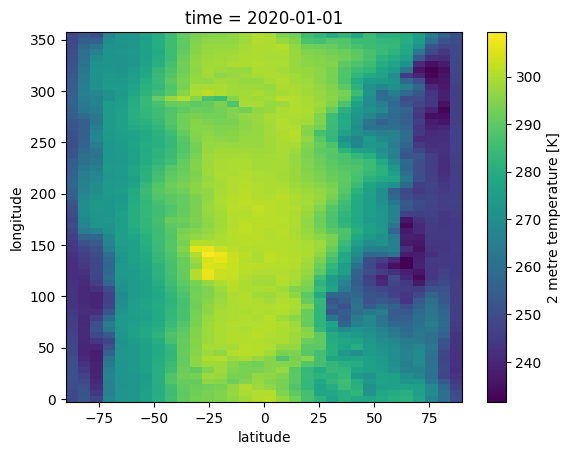

In [6]:
subset["2m_temperature"].isel(time=0).plot()

In [8]:
print(subset["2m_temperature"].shape)

print(subset["2m_temperature"].min().compute())

print(subset["2m_temperature"].max().compute())

print(subset["mean_sea_level_pressure"].min().compute())

print(subset["mean_sea_level_pressure"].max().compute())

(364, 64, 32)
<xarray.DataArray '2m_temperature' ()> Size: 4B
array(206.50925, dtype=float32)
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K
<xarray.DataArray '2m_temperature' ()> Size: 4B
array(317.39713, dtype=float32)
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K
<xarray.DataArray 'mean_sea_level_pressure' ()> Size: 4B
array(93857.39, dtype=float32)
Attributes:
    long_name:      Mean sea level pressure
    short_name:     msl
    standard_name:  air_pressure_at_mean_sea_level
    units:          Pa
<xarray.DataArray 'mean_sea_level_pressure' ()> Size: 4B
array(105379.12, dtype=float32)
Attributes:
    long_name:      Mean sea level pressure
    short_name:     msl
    standard_name:  air_pressure_at_mean_sea_level
    units:          Pa


In [9]:
subset["2m_temperature"].isel(time=0).values.shape

(64, 32)

In [10]:
subset_loaded = subset.compute()

In [11]:
variables = [
    "2m_temperature",
    "mean_sea_level_pressure",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind"
]

normalized = {}

for var in variables:
    data = subset_loaded[var]
    normalized[var] = (data - data.mean()) / data.std()

In [12]:
import numpy as np

X = []
y = []

for t in range(len(subset_loaded.time)-1):

    x_t = np.stack([
        normalized["2m_temperature"][t],
        normalized["mean_sea_level_pressure"][t],
        normalized["10m_u_component_of_wind"][t],
        normalized["10m_v_component_of_wind"][t]
    ], axis=-1)

    y_t = normalized["2m_temperature"][t+1]

    X.append(x_t)
    y.append(y_t)

X = np.array(X)
y = np.array(y)

y = np.expand_dims(y, axis=-1)

In [13]:
print(X.shape)
print(y.shape)

(363, 64, 32, 4)
(363, 64, 32, 1)


In [14]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [16]:
print(X.min(), X.max())
print(y.min(), y.max())

-5.274645970830799 4.852827094735041
-3.387047283260526 1.902981058069654


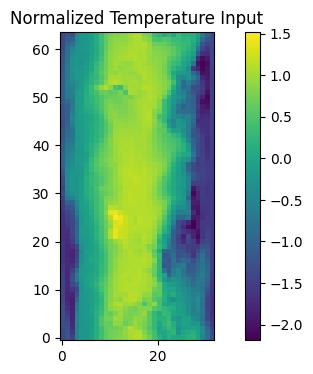

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.imshow(X[0,:,:,0], origin='lower')
plt.colorbar()
plt.title("Normalized Temperature Input")
plt.show()

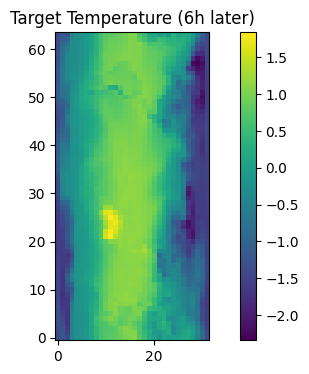

In [18]:
plt.figure(figsize=(8,4))
plt.imshow(y[0,:,:,0], origin='lower')
plt.colorbar()
plt.title("Target Temperature (6h later)")
plt.show()

In [19]:
import numpy as np

X = np.transpose(X, (0, 3, 1, 2))
y = np.transpose(y, (0, 3, 1, 2))

print(X.shape)
print(y.shape)

(363, 4, 64, 32)
(363, 1, 64, 32)


In [20]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(290, 4, 64, 32)
(73, 4, 64, 32)


In [21]:
import torch
from torch.utils.data import Dataset

class WeatherDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [22]:
train_dataset = WeatherDataset(
    X_train,
    y_train
)

test_dataset = WeatherDataset(
    X_test,
    y_test
)

In [23]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [24]:
import torch.nn as nn

class SmallUNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder

        self.enc1 = nn.Sequential(
            nn.Conv2d(4, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.MaxPool2d(2)

        # Bottleneck

        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        # Decoder

        self.up = nn.Upsample(
            scale_factor=2,
            mode='bilinear',
            align_corners=False
        )

        self.dec1 = nn.Sequential(
            nn.Conv2d(96, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.final = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )

    def forward(self, x):

        skip = self.enc1(x)

        x = self.pool(skip)

        x = self.bottleneck(x)

        x = self.up(x)

        x = torch.cat(
            [x, skip],
            dim=1
        )

        x = self.dec1(x)

        return self.final(x)

In [25]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = SmallUNet().to(device)

print(device)

cpu


In [26]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [28]:
print(X_train.shape)
print(y_train.shape)

sample_X, sample_y = train_dataset[0]

print(sample_X.shape)
print(sample_y.shape)

(290, 4, 64, 32)
(290, 1, 64, 32)
torch.Size([4, 64, 32])
torch.Size([1, 64, 32])


In [34]:
loss_history = []

num_epochs = 20

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = model(X_batch)

        loss = criterion(preds, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Loss: {avg_loss:.6f}"
    )

Epoch 1/20, Loss: 0.013930
Epoch 2/20, Loss: 0.014008
Epoch 3/20, Loss: 0.012536
Epoch 4/20, Loss: 0.012410
Epoch 5/20, Loss: 0.012180
Epoch 6/20, Loss: 0.013040
Epoch 7/20, Loss: 0.012133
Epoch 8/20, Loss: 0.011999
Epoch 9/20, Loss: 0.011251
Epoch 10/20, Loss: 0.010908
Epoch 11/20, Loss: 0.010704
Epoch 12/20, Loss: 0.010301
Epoch 13/20, Loss: 0.010471
Epoch 14/20, Loss: 0.009891
Epoch 15/20, Loss: 0.009505
Epoch 16/20, Loss: 0.009738
Epoch 17/20, Loss: 0.009517
Epoch 18/20, Loss: 0.009281
Epoch 19/20, Loss: 0.008851
Epoch 20/20, Loss: 0.009056


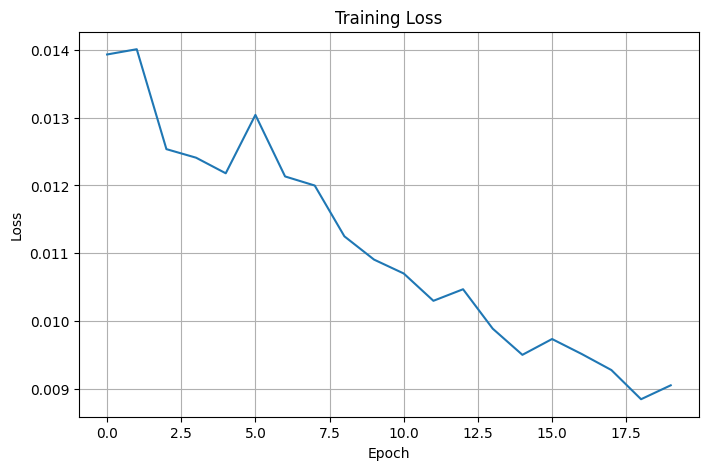

In [35]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [36]:
temp_std = subset_loaded["2m_temperature"].std().values

print("Temperature std:", temp_std)

rmse_kelvin = rmse * temp_std

print("RMSE in Kelvin:", rmse_kelvin)

Temperature std: 20.961679458618164
RMSE in Kelvin: 2.599649740638668


In [37]:
model.eval()

sample_X = torch.tensor(
    X_test[0:1],
    dtype=torch.float32
).to(device)

with torch.no_grad():
    pred = model(sample_X)

pred = pred.cpu().numpy()[0,0]
truth = y_test[0,0]

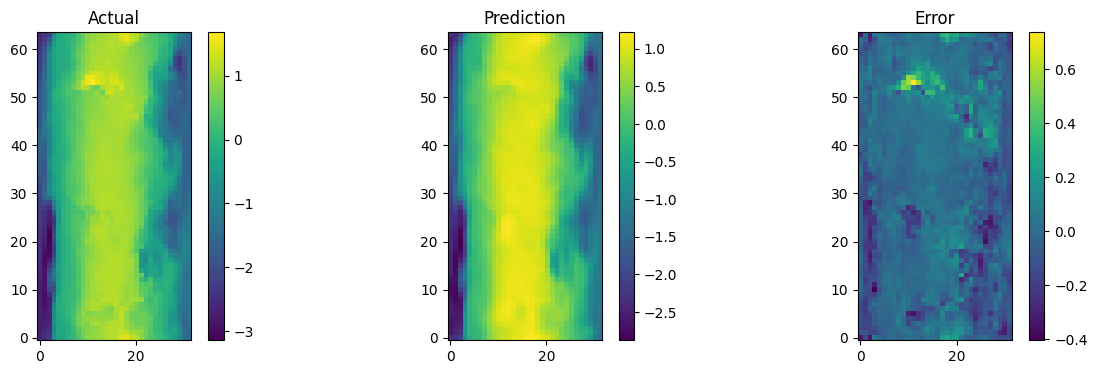

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(truth, origin="lower")
plt.title("Actual")

plt.colorbar()

plt.subplot(1,3,2)
plt.imshow(pred, origin="lower")
plt.title("Prediction")

plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(truth-pred, origin="lower")
plt.title("Error")

plt.colorbar()

plt.show()

In [39]:
mae = np.mean(
    np.abs(preds_all - targets_all)
)

print("MAE:", mae)

MAE: 0.08224454


In [40]:
print(ds.level.values)

[  50  100  150  200  250  300  400  500  600  700  850  925 1000]


In [41]:
z500 = ds["geopotential"].sel(level=500)

print(z500)

<xarray.DataArray 'geopotential' (time: 93544, longitude: 64, latitude: 32)> Size: 766MB
dask.array<getitem, shape=(93544, 64, 32), dtype=float32, chunksize=(100, 64, 32), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 748kB 1959-01-01 ... 2023-01-10T18:00:00
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
    level      int64 8B 500
Attributes:
    long_name:      Geopotential
    short_name:     z
    standard_name:  geopotential
    units:          m**2 s**-2


In [42]:
z500_subset = z500.sel(
    time=slice("2020-01-01", "2020-03-31")
)

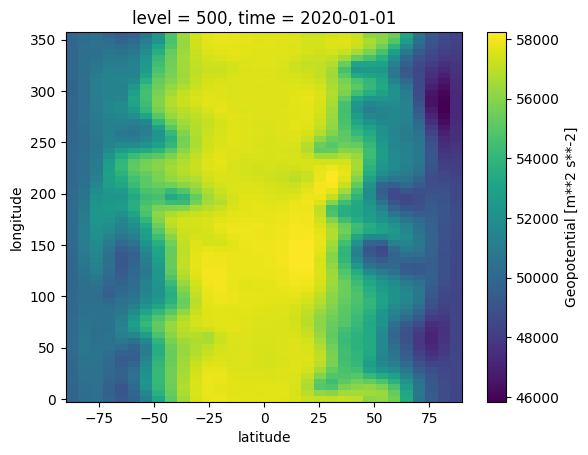

In [43]:
z500_subset.isel(time=0).plot()

In [44]:
print(z500_subset.min().compute())
print(z500_subset.max().compute())

<xarray.DataArray 'geopotential' ()> Size: 4B
array(45235.152, dtype=float32)
Coordinates:
    level    int64 8B 500
Attributes:
    long_name:      Geopotential
    short_name:     z
    standard_name:  geopotential
    units:          m**2 s**-2
<xarray.DataArray 'geopotential' ()> Size: 4B
array(58648.754, dtype=float32)
Coordinates:
    level    int64 8B 500
Attributes:
    long_name:      Geopotential
    short_name:     z
    standard_name:  geopotential
    units:          m**2 s**-2


In [45]:
z500_subset = z500_subset.compute()

subset2 = subset_loaded.copy()

subset2["geopotential_500"] = z500_subset

In [46]:
variables = [
    "2m_temperature",
    "mean_sea_level_pressure",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "geopotential_500"
]

normalized = {}

for var in variables:
    data = subset2[var]
    normalized[var] = (data - data.mean()) / data.std()

In [47]:
import numpy as np

X = []
y = []

for t in range(len(subset2.time)-1):

    x_t = np.stack([
        normalized["2m_temperature"][t],
        normalized["mean_sea_level_pressure"][t],
        normalized["10m_u_component_of_wind"][t],
        normalized["10m_v_component_of_wind"][t],
        normalized["geopotential_500"][t]
    ], axis=-1)

    y_t = normalized["2m_temperature"][t+1]

    X.append(x_t)
    y.append(y_t)

X = np.array(X)
y = np.array(y)

y = np.expand_dims(y, axis=-1)

In [48]:
print(X.shape)
print(y.shape)

(363, 64, 32, 5)
(363, 64, 32, 1)


In [49]:
X = np.transpose(X, (0, 3, 1, 2))
y = np.transpose(y, (0, 3, 1, 2))

print(X.shape)
print(y.shape)

(363, 5, 64, 32)
(363, 1, 64, 32)


In [50]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [51]:
import torch
from torch.utils.data import Dataset

class WeatherDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [52]:
train_dataset = WeatherDataset(
    X_train,
    y_train
)

test_dataset = WeatherDataset(
    X_test,
    y_test
)

In [53]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [56]:
print(X.shape)
print(y.shape)

(363, 5, 64, 32)
(363, 1, 64, 32)


In [55]:
import torch.nn as nn

class SmallUNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder

        self.enc1 = nn.Sequential(
            nn.Conv2d(5, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.MaxPool2d(2)

        # Bottleneck

        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        # Decoder

        self.up = nn.Upsample(
            scale_factor=2,
            mode='bilinear',
            align_corners=False
        )

        self.dec1 = nn.Sequential(
            nn.Conv2d(96, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.final = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )

    def forward(self, x):

        skip = self.enc1(x)

        x = self.pool(skip)

        x = self.bottleneck(x)

        x = self.up(x)

        x = torch.cat(
            [x, skip],
            dim=1
        )

        x = self.dec1(x)

        return self.final(x)

In [58]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = SmallUNet().to(device)

In [59]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [60]:
print(X_train.shape)

(290, 5, 64, 32)


In [61]:
print(model)

SmallUNet(
  (enc1): Sequential(
    (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (up): Upsample(scale_factor=2.0, mode='bilinear')
  (dec1): Sequential(
    (0): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (final): Conv2d(32, 1, kernel_size=(1, 1), stride=(1, 1))
)


In [62]:
loss_history = []

num_epochs = 20

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = model(X_batch)

        loss = criterion(preds, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Loss: {avg_loss:.6f}"
    )

Epoch 1/20, Loss: 0.364812
Epoch 2/20, Loss: 0.069407
Epoch 3/20, Loss: 0.039064
Epoch 4/20, Loss: 0.033021
Epoch 5/20, Loss: 0.029932
Epoch 6/20, Loss: 0.026625
Epoch 7/20, Loss: 0.024389
Epoch 8/20, Loss: 0.024624
Epoch 9/20, Loss: 0.020731
Epoch 10/20, Loss: 0.018680
Epoch 11/20, Loss: 0.018599
Epoch 12/20, Loss: 0.016671
Epoch 13/20, Loss: 0.016202
Epoch 14/20, Loss: 0.015245
Epoch 15/20, Loss: 0.014856
Epoch 16/20, Loss: 0.015087
Epoch 17/20, Loss: 0.014864
Epoch 18/20, Loss: 0.013662
Epoch 19/20, Loss: 0.012629
Epoch 20/20, Loss: 0.012899


In [63]:
model.eval()

preds_all = []
targets_all = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        preds = model(X_batch)

        preds_all.append(
            preds.cpu().numpy()
        )

        targets_all.append(
            y_batch.numpy()
        )

preds_all = np.concatenate(preds_all)
targets_all = np.concatenate(targets_all)

rmse = np.sqrt(
    np.mean(
        (preds_all - targets_all) ** 2
    )
)

print("RMSE:", rmse)

RMSE: 0.120215096


In [64]:
temp_std = subset2["2m_temperature"].std().values

rmse_kelvin = rmse * temp_std

print("RMSE (K):", rmse_kelvin)

RMSE (K): 2.5199102996272273
